# Data Exploration

Markdown

## Importing libraries

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import numpy as np

## Loading data

In [5]:
# Air Passengers Dataset
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv'
df = pd.read_csv(url, parse_dates=['Month'], index_col='Month')
df.columns = ['pasajeros']

In [8]:
df.tail(10)

,pasajeros
Month,
1960-03-01,419
1960-04-01,461
1960-05-01,472
1960-06-01,535
1960-07-01,622
1960-08-01,606
1960-09-01,508
1960-10-01,461
1960-11-01,390


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 144 entries, 1949-01-01 to 1960-12-01
Data columns (total 1 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   pasajeros  144 non-null    int64
dtypes: int64(1)
memory usage: 2.2 KB


<Axes: xlabel='Month'>

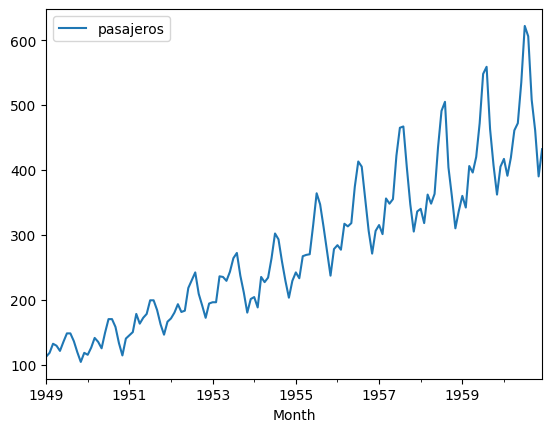

In [11]:
df.plot()

In [10]:
df.describe()

,pasajeros
count,144.000000
mean,280.298611
std,119.966317
min,104.000000
25%,180.000000
50%,265.500000
75%,360.500000
max,622.000000


In [13]:
# Synthetic discharge data
np.random.seed(42)
date_hidro = pd.date_range('2020-01-01', '2024-12-31', freq='D')
discharge = 100 + 20*np.sin(2*np.pi*date_hidro.dayofyear/365) + np.cumsum(np.random.normal(0, 2, len(date_hidro)))
df_hydro = pd.DataFrame({'discharge': discharge}, index=date_hidro)

In [14]:
df_hydro

,discharge
2020-01-01,101.337695
2020-01-02,101.405332
2020-01-03,103.044670
2020-01-04,106.434385
2020-01-05,106.309326
...,...
2024-12-27,257.780795
2024-12-28,256.824751
2024-12-29,257.506226
2024-12-30,258.734374


<Axes: >

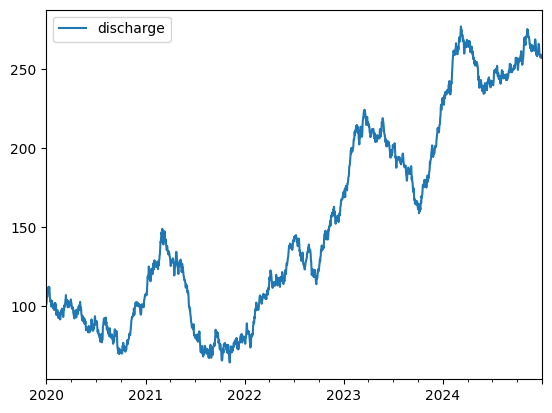

In [15]:
df_hydro.plot()

In [16]:
df_hydro.describe()


,discharge
count,1827.000000
mean,152.759778
std,65.000240
min,64.610703
25%,95.581501
50%,132.634002
75%,209.384873
max,276.656062


In [17]:
df_hydro.info()


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1827 entries, 2020-01-01 to 2024-12-31
Freq: D
Data columns (total 1 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   discharge  1827 non-null   float64
dtypes: float64(1)
memory usage: 28.5 KB


In [19]:
print("📊 Passenger data:")
print(df.head())
print("\n📊 Hydrological data:")
print(df_hydro.head())

📊 Passenger data:
            pasajeros
Month                
1949-01-01        112
1949-02-01        118
1949-03-01        132
1949-04-01        129
1949-05-01        121

📊 Hydrological data:
             discharge
2020-01-01  101.337695
2020-01-02  101.405332
2020-01-03  103.044670
2020-01-04  106.434385
2020-01-05  106.309326


## Visualization

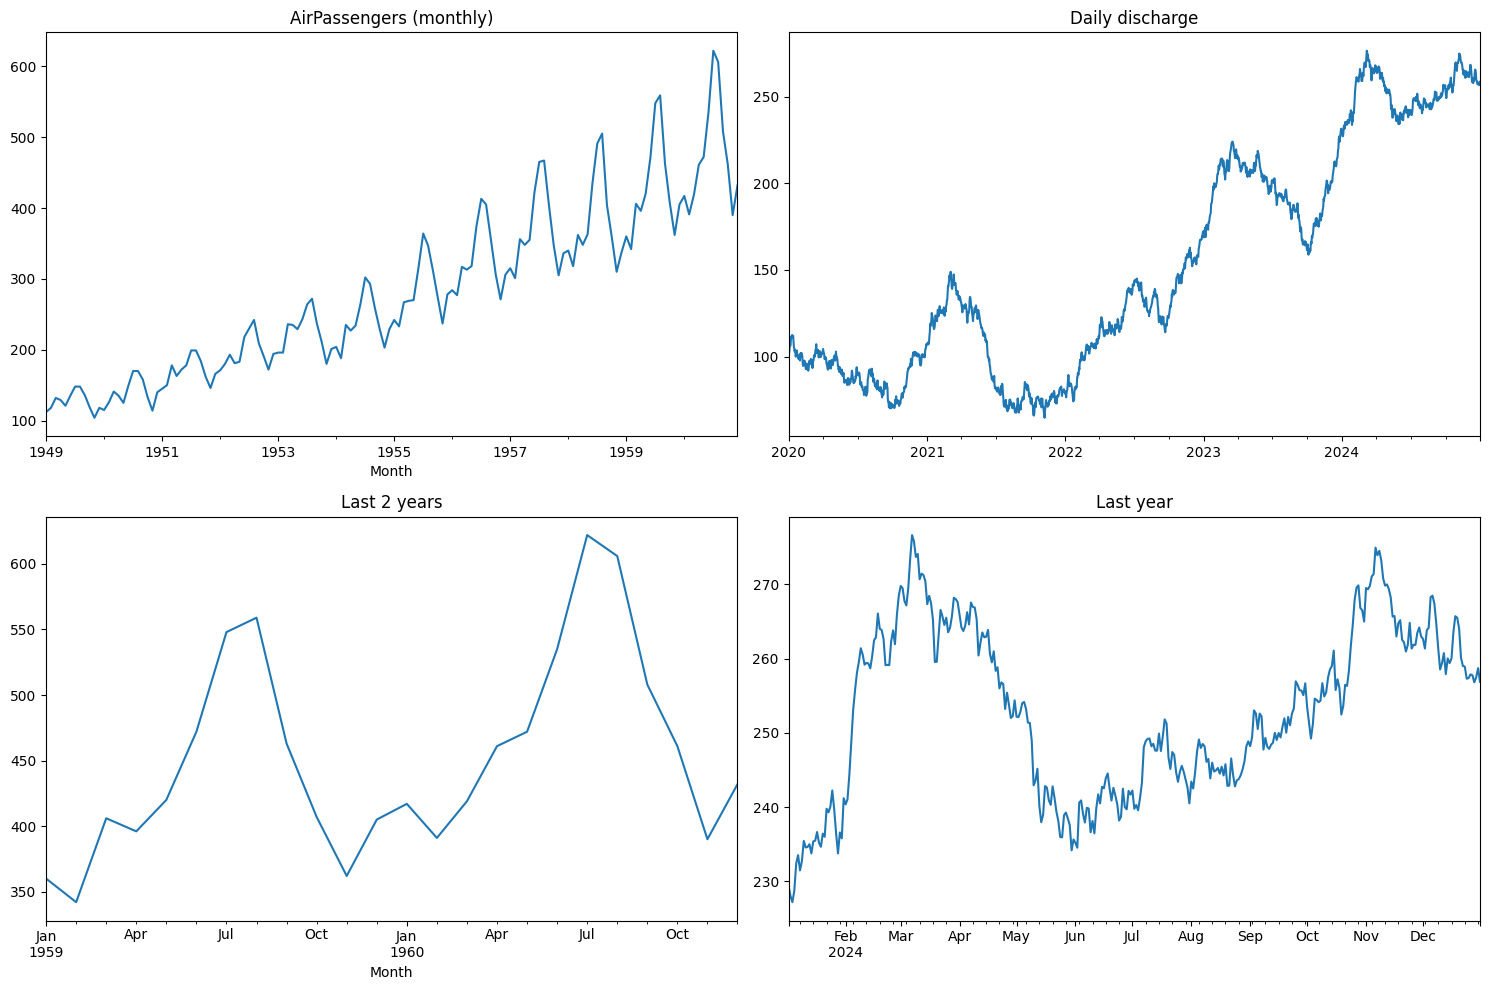

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
df['pasajeros'].plot(ax=axes[0,0], title='AirPassengers (monthly)')
df_hydro['discharge'].plot(ax=axes[0,1], title='Daily discharge')

# Zoom en subperíodos
df['pasajeros'].iloc[-24:].plot(ax=axes[1,0], title='Last 2 years')
df_hydro['discharge'].iloc[-365:].plot(ax=axes[1,1], title='Last year')

plt.tight_layout()
plt.show()

## Component decomposition

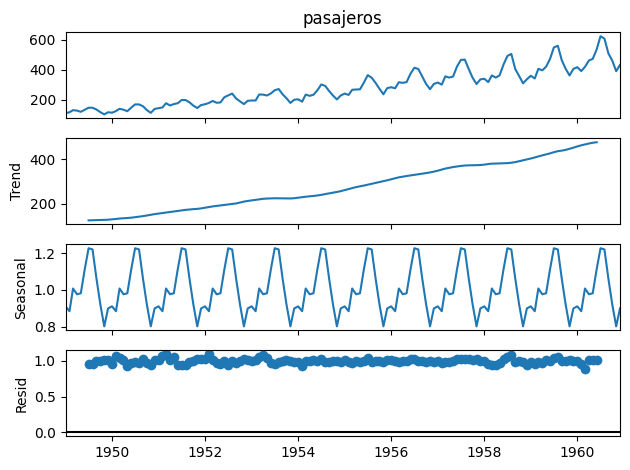

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose
decomp = seasonal_decompose(df['pasajeros'], model='multiplicative', period=12)
decomp.plot()
plt.show()

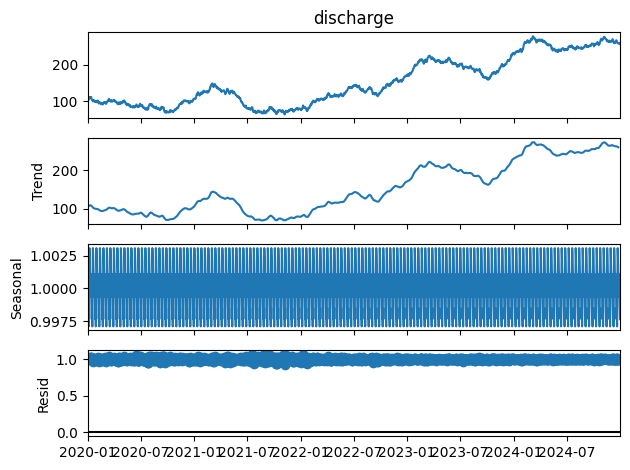

In [21]:
from statsmodels.tsa.seasonal import seasonal_decompose
decomp = seasonal_decompose(df_hydro['discharge'], model='multiplicative', period=12)
decomp.plot()
plt.show()

## Basic statistics

In [ ]:
df.describe()

,pasajeros
count,144.000000
mean,280.298611
std,119.966317
min,104.000000
25%,180.000000
50%,265.500000
75%,360.500000
max,622.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 144 entries, 1949-01-01 to 1960-12-01
Data columns (total 1 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   pasajeros  144 non-null    int64
dtypes: int64(1)
memory usage: 2.2 KB
